# M2SD HPC - TP 6
# Cuda - Conway Game of Life

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import time

In [ ]:
!uv pip install -q --system numba-cuda==0.4.0

In [ ]:
from numba import njit
from numba import stencil
from numba import config
from numba import cuda
config.CUDA_ENABLE_PYNVJITLINK = 1
config.CUDA_LOW_OCCUPANCY_WARNINGS = 0

In [ ]:
ctype = np.float64

### `init_grid`
- input: `shape`: (shape of a grid) ; `threshold`: density of the living cells
- output: `grid` 2darray of `ctype`

Initialize a random grid (2darray) of double float of dimension shape (the threshold help to define density)

In [ ]:
def init_grid(shape, threshold=0.50):
    """
    initialize a random  grid of double float
    of dimension shape (the threshold help to define density)
    """
    x = np.zeros(shape,dtype=ctype)
    r = np.random.random(shape)
    x[:,:] = (r> 1.0 - threshold)
    return x

### `enlarge_grid`
- input: `grid` 2darray of `ctype`
- output: `res_grid` 2darray of `ctype`

Add adds ghost (artificial/dead) cells to grid edges for boundary condition

In [ ]:
def enlarge_grid(grid):
    idim,jdim = grid.shape
    res_grid = np.zeros((idim + 2,jdim + 2),dtype=ctype)
    res_grid[1:-1,1:-1] = grid[:,:]
    return res_grid

### `life_step(grid)` :
- input: `grid` a 2darray of cells (ctype);
- output: `res_grid`  2darray ; the state of each cell of `grid` resulting from the application of the rules

Compute on life step (unroll version) for a complete enlarged grid.

In [ ]:
def life_step(grid):
    idim = grid.shape[0]
    jdim = grid.shape[1]
    res_grid = np.zeros((idim,jdim), dtype=ctype)
    for i in range(1,idim - 1):
        for j in range(1,jdim - 1):
            nb_neigh = 0 + grid[i - 1,j - 1] + grid[i - 1,j] + grid[i - 1,j + 1] \
                     + grid[i,j - 1]     + grid[ i,j + 1] \
                     + grid[i + 1,j - 1] + grid[i + 1,j] + grid[i + 1,j + 1]
            if nb_neigh == 2:
                res_grid[i,j] = grid[i,j]
            elif nb_neigh == 3:
                res_grid[i,j] = 1
    return res_grid

### `conway(grid,n)`
From an initial `grid` (ctype) create the enlarge grid, run n iterations of evolution, display the intermediate statistics (number of alive cells) and return `egrid` the last result grid.

In [ ]:
def conway(grid, n):
    """
    From an initial grid, run n iterations of evolution and display
    the intermediate statistics (number of alive cells)
    """
    egrid = enlarge_grid(grid)
    for i in range(n):
        alive = np.sum(egrid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        egrid = life_step(egrid)
    return egrid[1:-1,1:-1]

### Exemple on a little grid

In [ ]:
grid = init_grid((32,32), 0.5)

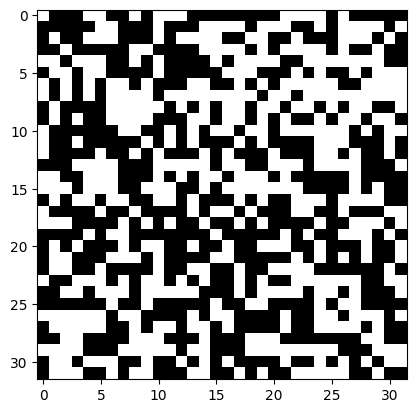

In [ ]:
plt.imshow(grid,cmap=plt.cm.binary)

In [ ]:
egrid = conway(grid, 5)

alive cells: 525: 51.27%
alive cells: 297: 29.00%
alive cells: 261: 25.49%
alive cells: 230: 22.46%
alive cells: 225: 21.97%


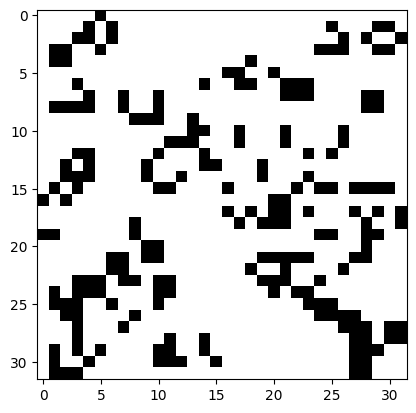

In [ ]:
plt.imshow(egrid,cmap=plt.cm.binary)

## Some grids

In [ ]:
grid_100 = init_grid((10,10), 0.5)
grid_10K = init_grid((100,100), 0.5)
grid_1M  = init_grid((1000,1000), 0.5)
grid_4M  = init_grid((2000,2000), 0.5)

## Time execution

In [ ]:
%time egrid_100 = enlarge_grid(grid_100)
%time egrid_10K = enlarge_grid(grid_10K)
%time egrid_1M = enlarge_grid(grid_1M)
%time egrid_4M = enlarge_grid(grid_4M)

CPU times: user 30 µs, sys: 6 µs, total: 36 µs
Wall time: 39.1 µs
CPU times: user 549 µs, sys: 0 ns, total: 549 µs
Wall time: 804 µs
CPU times: user 2.7 ms, sys: 1.77 ms, total: 4.46 ms
Wall time: 4.6 ms
CPU times: user 3.18 ms, sys: 15.1 ms, total: 18.3 ms
Wall time: 18.3 ms


In [ ]:
%time res_100 = life_step(egrid_100)
%time res_10K = life_step(egrid_10K)
%time res_1M = life_step(egrid_1M)
%time res_4M =life_step(egrid_4M)

CPU times: user 230 µs, sys: 0 ns, total: 230 µs
Wall time: 222 µs
CPU times: user 18.5 ms, sys: 868 µs, total: 19.4 ms
Wall time: 20.6 ms
CPU times: user 2.13 s, sys: 9.69 ms, total: 2.14 s
Wall time: 2.17 s
CPU times: user 8.59 s, sys: 27.9 ms, total: 8.62 s
Wall time: 8.7 s


In [ ]:
start = time.time()
res_100 = life_step(egrid_100)
time_100_py = time.time() - start

start = time.time()
res_10K = life_step(egrid_10K)
time_10K_py = time.time() - start

start = time.time()
res_1M = life_step(egrid_1M)
time_1M_py = time.time() - start

start = time.time()
res_4M = life_step(egrid_4M)
time_4M_py = time.time() - start

In [ ]:
%time res_100 = conway(egrid_100, 5)
%time res_10K = conway(egrid_10K, 5)
%time res_1M = conway(egrid_1M, 5)
%time res_4M = conway(egrid_4M, 5)

alive cells: 51: 35.42%
alive cells: 39: 27.08%
alive cells: 34: 23.61%
alive cells: 32: 22.22%
alive cells: 34: 23.61%
CPU times: user 3.18 ms, sys: 6 µs, total: 3.19 ms
Wall time: 4.36 ms
alive cells: 5004: 48.10%
alive cells: 2868: 27.57%
alive cells: 2732: 26.26%
alive cells: 2536: 24.38%
alive cells: 2587: 24.87%
CPU times: user 163 ms, sys: 2.03 ms, total: 165 ms
Wall time: 165 ms
alive cells: 498954: 49.70%
alive cells: 276844: 27.57%
alive cells: 255983: 25.50%
alive cells: 252984: 25.20%
alive cells: 240697: 23.97%
CPU times: user 9.64 s, sys: 16.7 ms, total: 9.66 s
Wall time: 9.69 s
alive cells: 1998948: 49.87%
alive cells: 1096962: 27.37%
alive cells: 1018085: 25.40%
alive cells: 1006108: 25.10%
alive cells: 958557: 23.92%
CPU times: user 40.9 s, sys: 127 ms, total: 41.1 s
Wall time: 41.4 s


## Exercice 1 numba `njit`
### Question 1.a
À l'aide du décorateur `njit` faire une version *jittée* de `life_step`.

In [ ]:
@njit
def life_step_njit(grid):
    idim = grid.shape[0]
    jdim = grid.shape[1]
    res_grid = np.zeros((idim,jdim), dtype=ctype)
    for i in range(1,idim - 1):
        for j in range(1,jdim - 1):
            nb_neigh = 0 + grid[i - 1,j - 1] + grid[i - 1,j] + grid[i - 1,j + 1] \
                     + grid[i,j - 1]     + grid[ i,j + 1] \
                     + grid[i + 1,j - 1] + grid[i + 1,j] + grid[i + 1,j + 1]
            if nb_neigh == 2:
                res_grid[i,j] = grid[i,j]
            elif nb_neigh == 3:
                res_grid[i,j] = 1
    return res_grid

### Question 1.b
Quel impact sur les performances ?

In [ ]:
%time res_100 = life_step_njit(egrid_100)
%time res_10K = life_step_njit(egrid_10K)
%time res_1M = life_step_njit(egrid_1M)
%time res_4M =life_step_njit(egrid_4M)

CPU times: user 1.25 s, sys: 85 ms, total: 1.34 s
Wall time: 1.58 s
CPU times: user 113 µs, sys: 2 µs, total: 115 µs
Wall time: 117 µs
CPU times: user 10.3 ms, sys: 0 ns, total: 10.3 ms
Wall time: 10.2 ms
CPU times: user 38.5 ms, sys: 2 µs, total: 38.5 ms
Wall time: 38.4 ms


In [ ]:
life_step_njit(egrid_100)

start = time.time()
res_100 = life_step_njit(egrid_100)
time_100_njit = time.time() - start

start = time.time()
res_10K = life_step_njit(egrid_10K)
time_10K_njit = time.time() - start

start = time.time()
res_1M = life_step_njit(egrid_1M)
time_1M_njit = time.time() - start

start = time.time()
res_4M = life_step_njit(egrid_4M)
time_4M_njit = time.time() - start

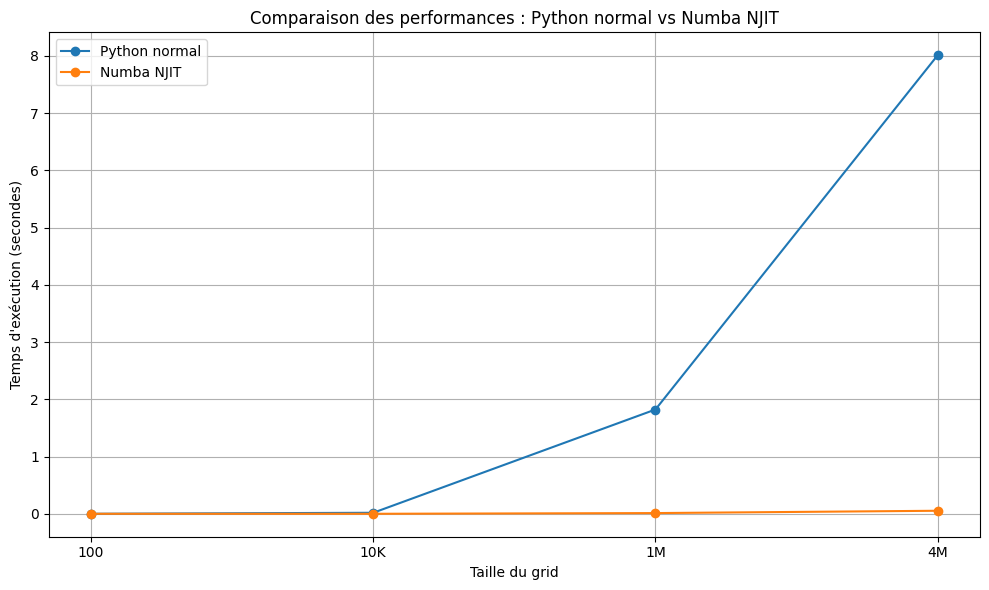

In [ ]:
sizes = ["100", "10K", "1M", "4M"]

time_normal = [time_100_py, time_10K_py, time_1M_py, time_4M_py]
time_njit   = [time_100_njit, time_10K_njit, time_1M_njit, time_4M_njit]

#Graphique
plt.figure(figsize=(10,6))
plt.plot(sizes, time_normal, marker='o', label="Python normal")
plt.plot(sizes, time_njit, marker='o', label="Numba NJIT")

plt.title("Comparaison des performances : Python normal vs Numba NJIT")
plt.xlabel("Taille du grid")
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

We can observe that the first run performed much slower in comparison with the unjited version, since the first run is responsable for building the C code alternative. But the following executions of the njited function performed considerably faster than the previous version.



## Exercice 2 numba `stencil`
### Question 2.a
Créer la fonction `life_step_st` qui utilise le décorateur `stencil` de numba pour calculer la grille résultat.

In [ ]:
@stencil # Deinition of the stencil kernel
def kernel_st(grid):
    nb_neigh = 0 + grid[-1,-1] + grid[-1,0] + grid[-1,1] \
              + grid[0,-1]     + grid[0,1] \
              + grid[1,-1] + grid[1,0] + grid[1,1]
    return nb_neigh

@njit
def life_step_st(grid):
    idim = grid.shape[0]
    jdim = grid.shape[1]
    res_grid = np.zeros((idim,jdim), dtype=ctype)
    nb_neigh = kernel_st(grid) # Application of the kernel
    for i in range(1,idim - 1):
        for j in range(1,jdim - 1):
            if nb_neigh[i,j] == 2:
                res_grid[i,j] = grid[i,j]
            elif nb_neigh[i,j] == 3:
                res_grid[i,j] = 1
    return res_grid

### Question 2.b
Quel impact sur les performances ?

In [ ]:
%time res_100 = life_step_st(egrid_100)
%time res_10K = life_step_st(egrid_10K)
%time res_1M = life_step_st(egrid_1M)
%time res_4M =life_step_st(egrid_4M)

CPU times: user 705 ms, sys: 20 ms, total: 725 ms
Wall time: 724 ms
CPU times: user 87 µs, sys: 1e+03 ns, total: 88 µs
Wall time: 89.9 µs
CPU times: user 8.11 ms, sys: 0 ns, total: 8.11 ms
Wall time: 8.03 ms
CPU times: user 29 ms, sys: 0 ns, total: 29 ms
Wall time: 28.8 ms


In [ ]:
life_step_st(egrid_100)

start = time.time()
res_100_st = life_step_st(egrid_100)
time_100_st = time.time() - start

start = time.time()
res_10K_st = life_step_st(egrid_10K)
time_10K_st = time.time() - start

start = time.time()
res_1M_st = life_step_st(egrid_1M)
time_1M_st = time.time() - start

start = time.time()
res_4M_st = life_step_st(egrid_4M)
time_4M_st = time.time() - start

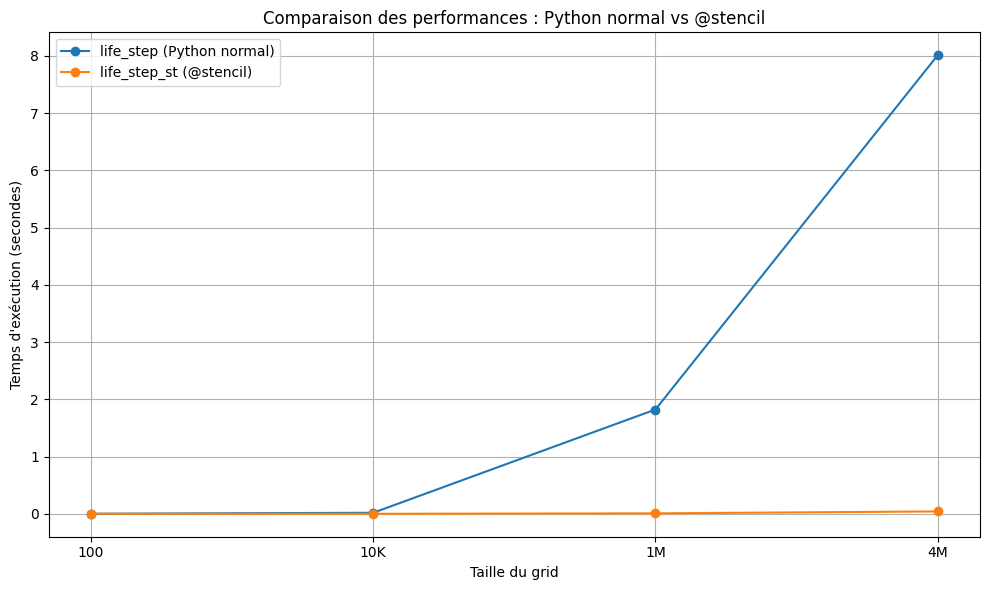

In [ ]:
sizes = ["100", "10K", "1M", "4M"]

time_normal = [time_100_py, time_10K_py, time_1M_py, time_4M_py]
time_st     = [time_100_st, time_10K_st, time_1M_st, time_4M_st]

plt.figure(figsize=(10,6))
plt.plot(sizes, time_normal, marker='o', label="life_step (Python normal)")
plt.plot(sizes, time_st, marker='o', label="life_step_st (@stencil)")

plt.title("Comparaison des performances : Python normal vs @stencil")
plt.xlabel("Taille du grid")
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


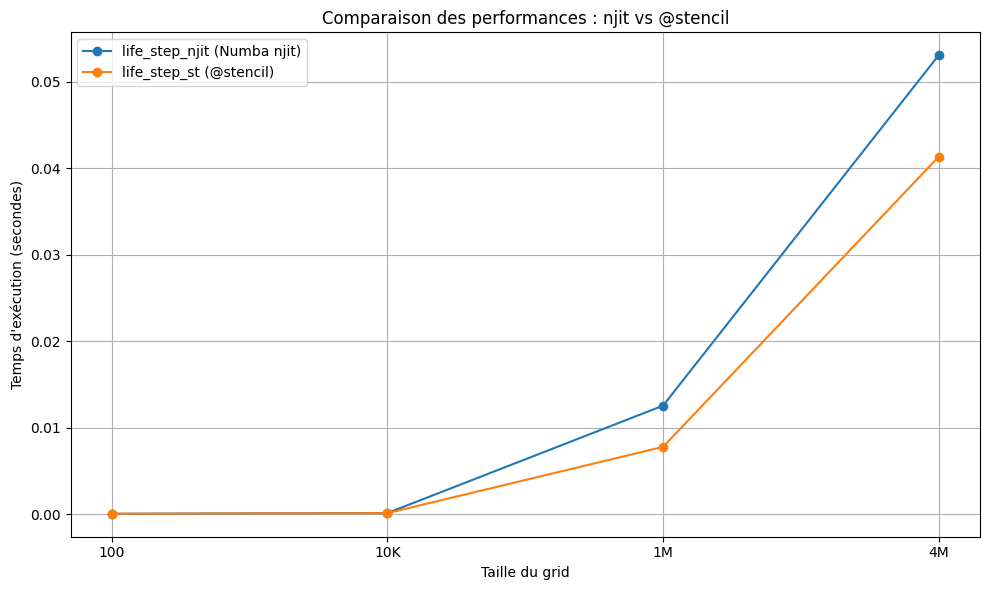

In [ ]:
time_njit = [time_100_njit, time_10K_njit, time_1M_njit, time_4M_njit]

plt.figure(figsize=(10,6))
# plt.plot(sizes, time_normal, marker='o', label="life_step (Python normal)")
plt.plot(sizes, time_njit,   marker='o', label="life_step_njit (Numba njit)")
plt.plot(sizes, time_st,     marker='o', label="life_step_st (@stencil)")

plt.title("Comparaison des performances : njit vs @stencil")
plt.xlabel("Taille du grid")
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


The stencil kernel is defined and then Numba generates the looping code necessary to apply that kernel to the grid when the function is called. Thus, it enabled a slightly higher performance in conjunction with a jited function.

## Exercice 3 Cuda
### Question 3.a
À partir de `life_step_st`créer un kernel cuda `life_step_cu` qui calcule une étape du jeu de la vie sur des GPUs nvidia de gamme tesla.
Tester l'exécution d'une étape du jeu de la vie sur GPU pour différentes tailles de grille.

In [ ]:

@cuda.jit
def life_step_cu(grid, res_grid):
    i, j = cuda.grid(2)
    idim = grid.shape[0]
    jdim = grid.shape[1]

    # On ne traite que l'intérieur; les bords restent 0
    if 0 < i < idim - 1 and 0 < j < jdim - 1:
        nb_neigh = (grid[i-1, j-1] + grid[i-1, j] + grid[i-1, j+1] +
                    grid[i,   j-1]                 + grid[i,   j+1] +
                    grid[i+1, j-1] + grid[i+1, j] + grid[i+1, j+1])

        if nb_neigh == 2:
            res_grid[i, j] = grid[i, j]
        elif nb_neigh == 3:
            res_grid[i, j] = 1
        else:
            res_grid[i, j] = 0
    else:
        # Bords : 0
        if i < idim and j < jdim:
            res_grid[i, j] = 0


In [ ]:
# egrid_100 = egrid_100.astype(np.float32)
egrid_10K = enlarge_grid(grid_10K)
ggrid_10K = cuda.to_device(egrid_10K)
g_res = cuda.device_array_like(egrid_10K)
width = np.int32(egrid_10K.shape[1])
dim1,dim2=egrid_10K.shape

threadsperblock = (32,32)
blockspergrid_x = (egrid_10K.shape[0] + threadsperblock[0] - 1) // threadsperblock[0]
blockspergrid_y = (egrid_10K.shape[1] + threadsperblock[1] - 1) // threadsperblock[1]
blockspergrid = (blockspergrid_x, blockspergrid_y)

life_step_cu[blockspergrid,threadsperblock](ggrid_10K, g_res)

res_10K_cu = g_res.copy_to_host()

res_10K=  life_step(egrid_10K)



In [ ]:
np.array_equal(res_10K, res_10K_cu)

True

In [ ]:
np.shape(res_10K_cu)

(102, 102)

### Question 3.b
Adapter le workflow complet conway pour effectuer plusieurs étapes du jeu de la vie en conservant les grilles sur GPUs. Dans un premier temps ne pas réaliser le calcul des statistiques.

In [ ]:
def conway_cu(grid, n):
    """
    From an initial grid, run n iterations of evolution and display
    the intermediate statistics (number of alive cells)
    """
    egrid = enlarge_grid(grid)
    ggrid = cuda.to_device(egrid)
    width = np.int32(egrid.shape[1])
    dim1,dim2=egrid.shape

    threadsperblock = (32,32)
    blockspergrid_x = (egrid.shape[0] + threadsperblock[0] - 1) // threadsperblock[0]
    blockspergrid_y = (egrid.shape[1] + threadsperblock[1] - 1) // threadsperblock[1]
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    alive = np.sum(egrid)
    print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')

    for i in range(n):
        g_res = cuda.device_array_like(egrid)
        life_step_cu[blockspergrid,threadsperblock](ggrid, g_res)
        res_cu = g_res.copy_to_host()
        ggrid = g_res

        alive = np.sum(res_cu)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
    return g_res[1:-1,1:-1]

In [ ]:
res_conway_cu = conway_cu(egrid_100, 5)

alive cells: 51: 35.42%
alive cells: 39: 27.08%
alive cells: 34: 23.61%
alive cells: 32: 22.22%
alive cells: 34: 23.61%
alive cells: 38: 26.39%


In [ ]:
res_100 = conway(egrid_100, 5)

alive cells: 51: 35.42%
alive cells: 39: 27.08%
alive cells: 34: 23.61%
alive cells: 32: 22.22%
alive cells: 34: 23.61%


In [ ]:
np.array_equal(res_conway_cu, res_100)

True

### Question 3.c
Estimer les temps d'exécution du workflow complet pour différentes taille de grille

In [ ]:
%time res_100_cu = conway_cu(egrid_100, 5)
%time res_10K_cu = conway_cu(egrid_10K, 5)
%time res_1M_cu = conway_cu(egrid_1M, 5)
%time res_4M_cu =conway_cu(egrid_4M, 5)

alive cells: 51: 35.42%
alive cells: 39: 27.08%
alive cells: 34: 23.61%
alive cells: 32: 22.22%
alive cells: 34: 23.61%
alive cells: 38: 26.39%
CPU times: user 3.2 ms, sys: 3 µs, total: 3.21 ms
Wall time: 3.83 ms
alive cells: 5004: 48.10%
alive cells: 2868: 27.57%
alive cells: 2732: 26.26%
alive cells: 2536: 24.38%
alive cells: 2587: 24.87%
alive cells: 2391: 22.98%
CPU times: user 2.01 ms, sys: 0 ns, total: 2.01 ms
Wall time: 2.03 ms
alive cells: 498954: 49.70%
alive cells: 276844: 27.57%
alive cells: 255983: 25.50%
alive cells: 252984: 25.20%
alive cells: 240697: 23.97%
alive cells: 234656: 23.37%
CPU times: user 16.7 ms, sys: 11 ms, total: 27.7 ms
Wall time: 27.9 ms
alive cells: 1998948: 49.87%
alive cells: 1096962: 27.37%
alive cells: 1018085: 25.40%
alive cells: 1006108: 25.10%
alive cells: 958557: 23.92%
alive cells: 930170: 23.21%
CPU times: user 77.5 ms, sys: 22 ms, total: 99.5 ms
Wall time: 99.4 ms


In [ ]:
res_4M=  conway(egrid_4M,5)

np.array_equal(res_4M_cu, res_4M)

alive cells: 1998948: 49.87%
alive cells: 1096962: 27.37%
alive cells: 1018085: 25.40%
alive cells: 1006108: 25.10%
alive cells: 958557: 23.92%


True